In [2]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import kornia as K
import kornia.feature as KF
from scipy.optimize import linear_sum_assignment
import matplotlib.patches as patches


In [12]:

# --- Конфигурация ---
YOLO_WEIGHTS_PATH = 'yolo_weights/best.pt' 
# Если весов нет для теста, используем yolo8n-seg для работоспособности кода:
try:
    yolo_model = YOLO(YOLO_WEIGHTS_PATH)
except:
    print(f"WARN: Не найдены веса по пути {YOLO_WEIGHTS_PATH}, качаю yolo8n-seg")
    yolo_model = YOLO('yolov8n-seg.pt')

IMAGE1_PATH = 'bush_1.png'
IMAGE2_PATH = 'bush_2.png'

# Параметры камеры (Примерные для Isaac Sim, если не указаны).
# f - фокусное расстояние в пикселях, cx,cy - оптический центр.
# Для  локализации это КРИТИЧНО. Пока используем generic значения.
# Пользователь в пропозале упомянул Isaac Sim, нужно взять параметры оттуда.
W, H = 1920, 1080 # Предполагаемый размер изображения
f = 1000.0
cx, cy = W/2, H/2
K_matrix = np.array([[f, 0, cx],
                    [0, f, cy],
                    [0, 0, 1]], dtype=np.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем устройство: {device}")


Используем устройство: cpu


In [65]:
n = 4096

import cv2
import torch
import numpy as np
import kornia as K
import kornia.feature as KF
from scipy.optimize import linear_sum_assignment

class StrawberryTracker:
    def __init__(self, yolo_model, device):
        self.device = device
        self.yolo = yolo_model
        
        print("Загрузка моделей DISK и LightGlue...")
        self.disk = KF.DISK.from_pretrained('depth').to(device)
        self.lg = KF.LightGlue('disk').to(device).eval()

    def prepare_kornia_tensor(self, img_rgb):
        t = torch.from_numpy(img_rgb).permute(2, 0, 1).unsqueeze(0).float() / 255.0
        return t.to(self.device)

    def apply_bbox_mask(self, img_tensor, boxes):
        """
        Заливает черным цветом всё, что находится вне Bounding Boxes.
        Заставляет DISK искать точки только на ягодах.
        """
        mask = torch.zeros_like(img_tensor)
        _, _, H, W = img_tensor.shape
        
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            # Ограничиваем координаты размерами картинки на всякий случай
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(W, x2), min(H, y2)
            mask[:, :, y1:y2, x1:x2] = 1.0
            
        return img_tensor * mask

    def get_best_box_for_point(self, p, boxes):
        """
        Если точка попала в несколько рамок, отдаем её самой маленькой рамке.
        Это решает проблему "жадного" воровства точек.
        """
        best_idx = -1
        min_area = float('inf')
        for idx, box in enumerate(boxes):
            x1, y1, x2, y2 = box
            if x1 <= p[0] <= x2 and y1 <= p[1] <= y2:
                area = (x2 - x1) * (y2 - y1)
                if area < min_area:
                    min_area = area
                    best_idx = idx
        return best_idx

    def associate_berries(self, img1_path, img2_path):
        orig_img1 = cv2.cvtColor(cv2.imread(img1_path), cv2.COLOR_BGR2RGB)
        orig_img2 = cv2.cvtColor(cv2.imread(img2_path), cv2.COLOR_BGR2RGB)

        # 1. YOLO Сегментация с ЖЕСТКИМ NMS (iou=0.45 убивает дубликаты)
        res1 = self.yolo.predict(orig_img1, verbose=False, iou=0.45)[0]
        res2 = self.yolo.predict(orig_img2, verbose=False, iou=0.45)[0]

        boxes1 = res1.boxes.xyxy.cpu().numpy() if res1.boxes else []
        boxes2 = res2.boxes.xyxy.cpu().numpy() if res2.boxes else []

        print(f"YOLO (после фильтрации дубликатов): Ягод на Кадре 1: {len(boxes1)}, Кадре 2: {len(boxes2)}")

        kimg1 = self.prepare_kornia_tensor(orig_img1)
        kimg2 = self.prepare_kornia_tensor(orig_img2)

        # 2. Маскируем фон, чтобы точки искались только на ягодах!
        kimg1_masked = self.apply_bbox_mask(kimg1, boxes1)
        kimg2_masked = self.apply_bbox_mask(kimg2, boxes2)

        # 3. DISK & LightGlue 
        with torch.inference_mode():
            # Извлекаем точки из замаскированных картинок
            features1 = self.disk(kimg1_masked, n=n, pad_if_not_divisible=True)
            features2 = self.disk(kimg2_masked, n=n, pad_if_not_divisible=True)
            
            feats1, feats2 = features1[0], features2[0]

            image0 = {
                "keypoints": feats1.keypoints[None], 
                "descriptors": feats1.descriptors[None],
                "image_size": torch.tensor(kimg1.shape[-2:][::-1]).view(1, 2).to(self.device)
            }
            image1 = {
                "keypoints": feats2.keypoints[None],
                "descriptors": feats2.descriptors[None],
                "image_size": torch.tensor(kimg2.shape[-2:][::-1]).view(1, 2).to(self.device)
            }

            matches = self.lg({"image0": image0, "image1": image1})

        kp1 = feats1.keypoints.cpu().numpy()
        kp2 = feats2.keypoints.cpu().numpy()

        if 'matches' in matches:
            m_indices = matches['matches'][0].cpu().numpy()
            m_kp1 = kp1[m_indices[:, 0]]
            m_kp2 = kp2[m_indices[:, 1]]
        elif 'matches0' in matches:
            matches_indices = matches['matches0'][0].cpu().numpy()
            valid_m_mask = matches_indices != -1
            m_kp1 = kp1[valid_m_mask]
            m_kp2 = kp2[matches_indices[valid_m_mask]]
        else:
            m_kp1, m_kp2 = np.array([]), np.array([])

        print(f"Найдено {len(m_kp1)} сфокусированных совпадений признаков (строго на ягодах)")

        # 4. Умная фильтрация матчей по Bounding Boxes
        n_berries1 = len(boxes1)
        n_berries2 = len(boxes2)
        match_counts_matrix = np.zeros((n_berries1, n_berries2))

        berry_keypoints_matches = [] 

        for i in range(len(m_kp1)):
            p1 = m_kp1[i].astype(int)
            p2 = m_kp2[i].astype(int)

            # Получаем индекс рамки с наименьшей площадью
            berry_id1 = self.get_best_box_for_point(p1, boxes1)
            berry_id2 = self.get_best_box_for_point(p2, boxes2)

            if berry_id1 != -1 and berry_id2 != -1:
                match_counts_matrix[berry_id1, berry_id2] += 1
                berry_keypoints_matches.append((m_kp1[i], m_kp2[i], berry_id1, berry_id2))

        # 5. Re-ID (Венгерский алгоритм)
        row_ind, col_ind = linear_sum_assignment(-match_counts_matrix)

        final_associations = [] 
        # Порог снижен до 3, так как теперь нет "мусорных" точек с листьев
        MATCH_THRESHOLD = 3 

        for b1, b2 in zip(row_ind, col_ind):
            if match_counts_matrix[b1, b2] >= MATCH_THRESHOLD:
                final_associations.append((b1, b2))

        landmark_matches_kp1 = []
        landmark_matches_kp2 = []
        
        relevant_berry_pairs = set(final_associations)
        for m1, m2, id1, id2 in berry_keypoints_matches:
            if (id1, id2) in relevant_berry_pairs:
                landmark_matches_kp1.append(m1)
                landmark_matches_kp2.append(m2)

        return (orig_img1, orig_img2, np.array(landmark_matches_kp1), np.array(landmark_matches_kp2), 
                boxes1, boxes2, final_associations)

In [66]:

# --- Задача 2: Локализация по автоматически создающимся лендмаркам ---
def localize_camera(m_kp1, m_kp2, K_matrix):
    """
    Рассчитывает относительный поворот и смещение камеры на основе лендмарков
    внутри ягод.
    """
    if len(m_kp1) < 5:
        print("WARN: Недостаточно лендмарков для локализации (нужно >= 5)")
        return np.eye(3), np.zeros((3, 1)), None

    # 1. Essential Matrix с RANSAC (чтобы отфильтровать точки, не попавшие в геометрию)
    # Это ключевой шаг локализации SLAM.
    E, mask = cv2.findEssentialMat(m_kp1, m_kp2, K_matrix, method=cv2.RANSAC, prob=0.999, threshold=1.0)
    
    # 2. Декомпозиция E -> R, T
    # recoveryPose извлекает R и смещение T, масштабированное на неизвестный коэффициент
    _, R, t, _ = cv2.recoverPose(E, m_kp1, m_kp2, K_matrix, mask=mask)
    
    # In-liers (точки, которые прошли RANSAC и epipolar check)
    inliers1 = m_kp1[mask.ravel()==1]
    inliers2 = m_kp2[mask.ravel()==1]

    print(f"SLAM: Локализация успешна. Используется {len(inliers1)} лендмарков из {len(m_kp1)} начальных ягодных матчей.")
    
    return R, t, mask, inliers1, inliers2



In [67]:

# --- Визуализация ---
def plot_results(img1, img2, kp1, kp2, boxes1, boxes2, associations):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    ax1.imshow(img1)
    ax1.set_title("Кадр 1: Найденные ягоды (YOLO) и Re-ID")
    ax1.axis('off')

    ax2.imshow(img2)
    ax2.set_title("Кадр 2: Соответствующие ягоды (SuperPoint+LightGlue)")
    ax2.axis('off')

    # Словарь для цветов ягод, чтобы ID были одинаковыми
    np.random.seed(42) # Зафиксируем цвета
    colors = np.random.rand(max(len(boxes1), len(boxes2)) + 1, 3)

    # Отрисовка ID на первом кадре
    for i, box in enumerate(boxes1):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=colors[i], facecolor='none')
        ax1.add_patch(rect)
        ax1.text(x1, y1, f'ID {i}', color='white', backgroundcolor=colors[i], fontsize=12)

    # Отрисовка соответствующих ID на втором кадре
    # Мы присваиваем ID с первого кадра соответствующим ягодам на втором
    berry2_to_id1_map = {b2: b1 for b1, b2 in associations}

    for j, box in enumerate(boxes2):
        x1, y1, x2, y2 = box
        
        if j in berry2_to_id1_map:
            color_id = berry2_to_id1_map[j]
            label = f'ID {color_id} (Matched)'
            edgecolor = colors[color_id]
        else:
            # Ягода не сопоставлена, используем серый цвет
            label = 'New/Unknown'
            edgecolor = [0.5, 0.5, 0.5]

        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=edgecolor, facecolor='none')
        ax2.add_patch(rect)
        ax2.text(x1, y1, label, color='white', backgroundcolor=edgecolor, fontsize=12)

    # Визуализация лендмарков, по которым прошла локализация
    ax1.scatter(kp1[:, 0], kp1[:, 1], c='lime', s=10, marker='.', label='Landmarks')
    ax2.scatter(kp2[:, 0], kp2[:, 1], c='lime', s=10, marker='.', label='Landmarks')
    
    ax1.legend()
    plt.tight_layout()
    plt.show()


In [68]:

# --- Основной цикл ---
print(">>> Шаг 1: Трекинг ягод (Approach 3)...")
tracker = StrawberryTracker(yolo_model, device)
img1, img2, m_kp1, m_kp2, boxes1, boxes2, associations = tracker.associate_berries(IMAGE1_PATH, IMAGE2_PATH)


>>> Шаг 1: Трекинг ягод (Approach 3)...
Загрузка моделей DISK и LightGlue...
Loaded LightGlue model
YOLO (после фильтрации дубликатов): Ягод на Кадре 1: 12, Кадре 2: 8
Найдено 278 сфокусированных совпадений признаков (строго на ягодах)


In [69]:

print("\n>>> Шаг 2: Локализация по автоматически созающимся лендмаркам...")
R, t, mask, inliers1, inliers2 = localize_camera(m_kp1, m_kp2, K_matrix)



>>> Шаг 2: Локализация по автоматически созающимся лендмаркам...
SLAM: Локализация успешна. Используется 96 лендмарков из 248 начальных ягодных матчей.


In [70]:

# Вывод вектора перемещения камеры
# (Единицы условны, т.к. из Essential Matrix извлекается T без масштаба)
print(f"\nОтносительный поворот (R matrix):\n{R}")
print(f"Относительное смещение камеры (t vector, normalized):\n{t.ravel()}")



Относительный поворот (R matrix):
[[    0.99897   0.0056238    0.044942]
 [ -0.0053366     0.99996  -0.0065098]
 [  -0.044977   0.0062633     0.99897]]
Относительное смещение камеры (t vector, normalized):
[    0.50937      0.1928    -0.83867]



>>> Визуализация результатов...


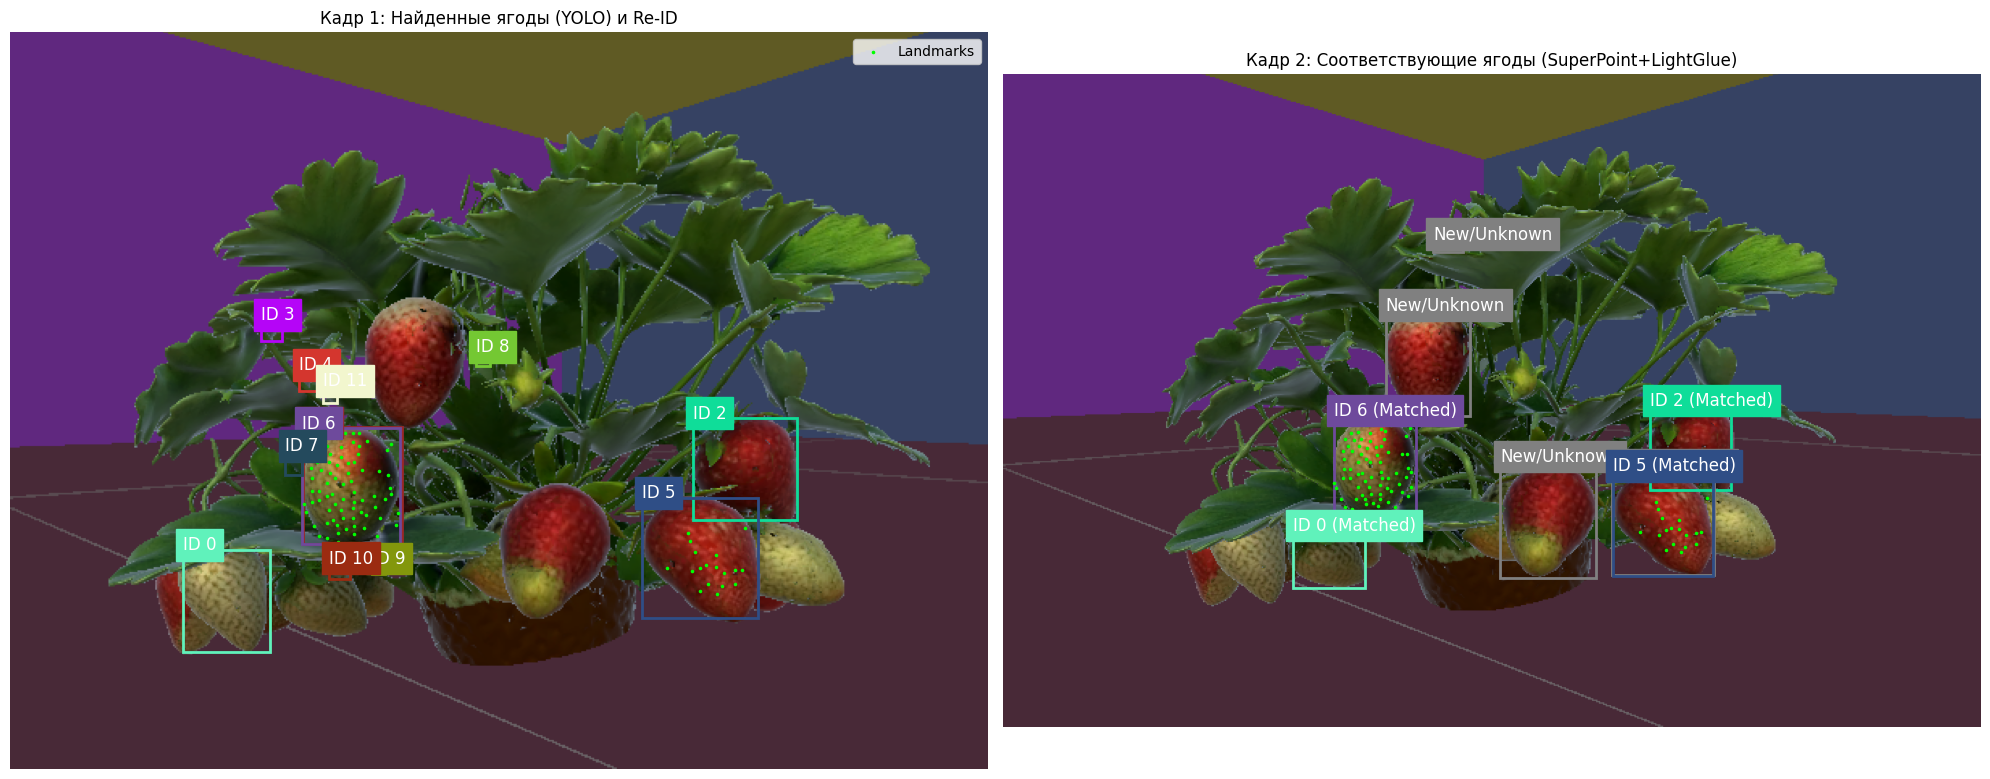

In [71]:

# --- Шаг 3: Визуализация Re-ID ---
print("\n>>> Визуализация результатов...")
plot_results(img1, img2, inliers1, inliers2, boxes1, boxes2, associations)

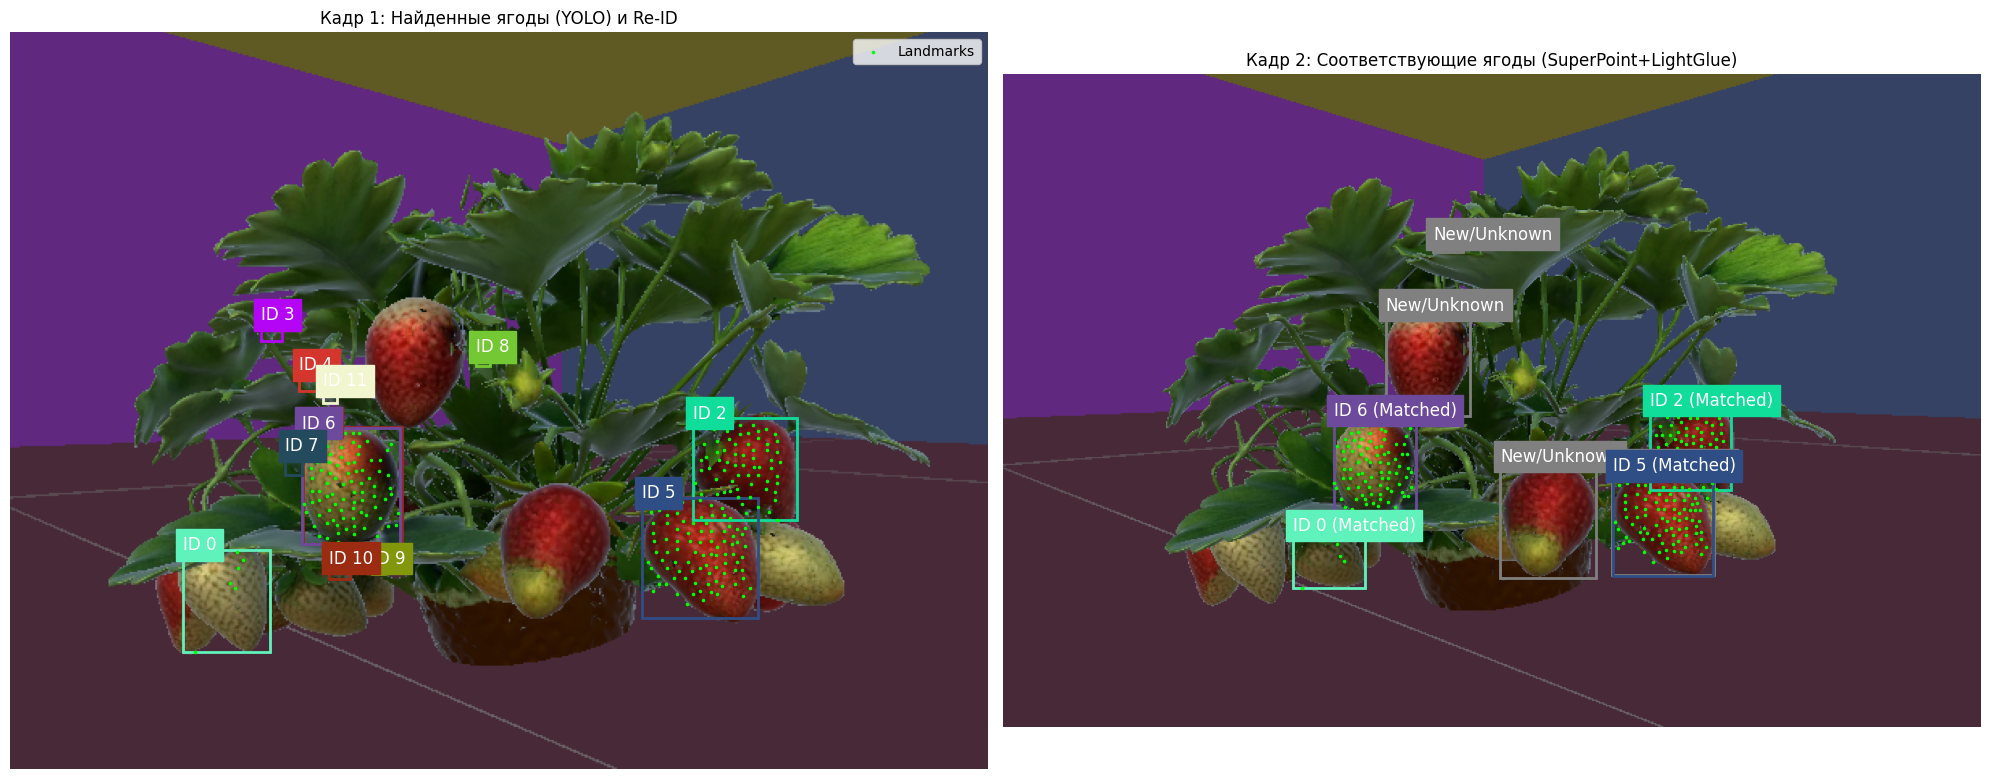

In [ ]:
#Новый вызов для дебага (передаем сырые m_kp1 и m_kp2):
plot_results(img1, img2, m_kp1, m_kp2, boxes1, boxes2, associations)